# Telco Customer Churn

# The data set includes information about :
- Customers who left within the last month column is called Chun
- Services that each customer has signed up phone, multiple lines, internet, online security, online backup, device protection, tech support, asd streaming TV and moves
- Customer account informan how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about custrs gender, age range, and if they have partners and depen

# Features Overview :
- customerID: Unique customer identifier.
- gender: Customer's gender.
- SeniorCitizen: Indicates if the customer is 65 or older: Yes(1), No(0)
- Partner: Indicates if customer has a partner .
- Dependents: Indicates if the customer lives with any dependents: Yes, No. Dependents could be children, parents, grandparents, etc.
- tenure: Number of months with the company.
- PhoneService: Indicates if the customer subscribes to home phone service with the company: Yes, No
- MultipleLines: Indicates if the customer subscribes to multiple telephone lines with the company: Yes, No
- InternetService: Indicates if the customer subscribes to Internet service with the company: No, DSL, Fiber Optic, Cable.
- OnlineSecurity: Indicates if the customer subscribes to an additional online security service provided by the company: Yes, No
- OnlineBackup: Indicates if the customer subscribes to an additional online backup service provided by the company: Yes, No
- DeviceProtection: Indicates if the customer subscribes to an additional device protection plan for their Internet equipment provided by the company: Yes, No
- TechSupport: Indicates if the customer subscribes to an additional technical support plan from the company with reduced wait times: Yes, No
- StreamingTV: Indicates if the customer uses their Internet service to stream television programing from a third party provider: Yes, No. The company does not charge an additional fee for this service.
- StreamingMovies: Indicates if the customer uses their Internet service to stream movies from a third party provider: Yes, No. The company does not charge an additional fee for this service.
- Contract: Indicates the customer’s current contract type: Month-to-Month, One Year, Two Year.
- PaperlessBilling: Indicates if the customer has chosen paperless billing: Yes, No.
- PaymentMethod: Indicates how the customer pays their bill: Bank Withdrawal, Credit Card, Mailed Check.
- MonthlyCharges: Indicates the customer’s current total monthly charge for all their services from the company.
- TotalCharges: Indicates the customer’s total charges, calculated to the end of the quarter specified above.
- Churn: Yes = the customer left the company this quarter. No = the customer remained with the company. Directly related to Churn Value.

In [242]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [ ]:
df = pd.read_csv(r'C:\Users\petabyte\Desktop\NTI\data\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EDA

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [78]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].dtype

dtype('float64')

In [80]:
df = df.drop(["customerID"], axis=1)

In [82]:
df.duplicated().sum()

22

In [83]:
df=df.drop_duplicates()

In [86]:
df.describe(include="all")

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7021,7021.000000,7021,7021,7021.000000,7021,7021,7021,7021,7021,7021,7021,7021,7021,7021,7021,7021,7021.000000,7010.000000,7021
unique,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,3541,NaN,3619,4911,NaN,6339,3368,3090,3490,3080,3087,3465,2802,2777,3853,4161,2359,NaN,NaN,5164
mean,NaN,0.162512,NaN,NaN,32.469449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.851894,2290.353388,NaN
std,NaN,0.368947,NaN,NaN,24.534965,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.069001,2266.820832,NaN
min,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.750000,408.312500,NaN
50%,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.400000,1403.875000,NaN
75%,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.900000,3807.837500,NaN


In [88]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

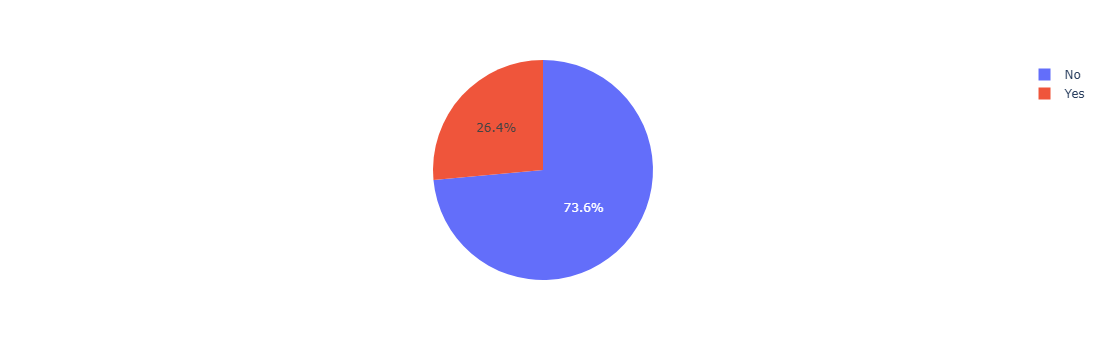

In [90]:
x = px.pie(df, names='Churn')
x.show()

# Distribution of feature

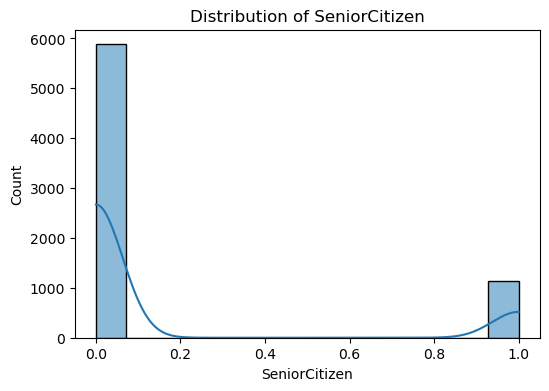

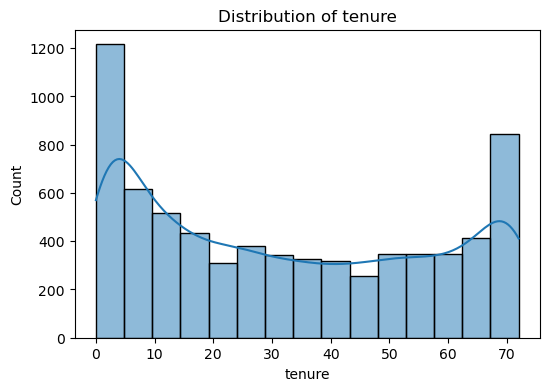

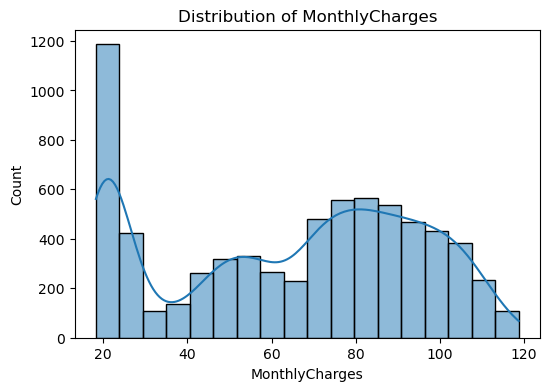

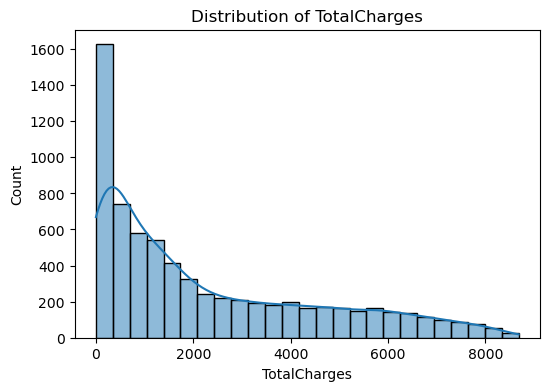

In [93]:
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [94]:
categories = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup", 
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]
for col in categories:
    print(col, ":", df[col].unique())


MultipleLines : ['No phone service' 'No' 'Yes']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']


In [97]:
for col in categories:
    df[col] = df[col].replace({"No phone service": "No", "No internet service": "No"})

In [99]:
object_cols = df.select_dtypes(include="object").columns

print(object_cols)

for col in object_cols:
    print(f"\n{col} → unique values:")
    print(df[col].unique())


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

gender → unique values:
['Female' 'Male']

Partner → unique values:
['Yes' 'No']

Dependents → unique values:
['No' 'Yes']

PhoneService → unique values:
['No' 'Yes']

MultipleLines → unique values:
['No' 'Yes']

InternetService → unique values:
['DSL' 'Fiber optic' 'No']

OnlineSecurity → unique values:
['No' 'Yes']

OnlineBackup → unique values:
['Yes' 'No']

DeviceProtection → unique values:
['No' 'Yes']

TechSupport → unique values:
['No' 'Yes']

StreamingTV → unique values:
['No' 'Yes']

StreamingMovies → unique values:
['No' 'Yes']

Contract → unique values:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling → unique values:
['Yes' 'No']

PaymentMethod → unique values:
['Electr

In [101]:
X = df.drop("Churn", axis=1) 
y = df["Churn"]               

# Encoding

In [104]:

cat_cols = X.select_dtypes(include="object").columns

X = pd.get_dummies(X, columns=cat_cols, drop_first=True).astype(int)

print("Encoding:", X.shape)
X.head()


Encoding: (7021, 23)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29,29,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56,1889,1,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,1
2,0,2,53,108,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42,1840,1,0,0,0,0,0,...,1,1,0,0,1,0,0,0,0,0
4,0,2,70,151,0,0,0,1,0,1,...,0,0,0,0,0,0,1,0,1,0


In [106]:
le = LabelEncoder()

y = le.fit_transform(y)
y = pd.Series(y, name="Churn", index=X.index)
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int32

# Correlation Heatmap

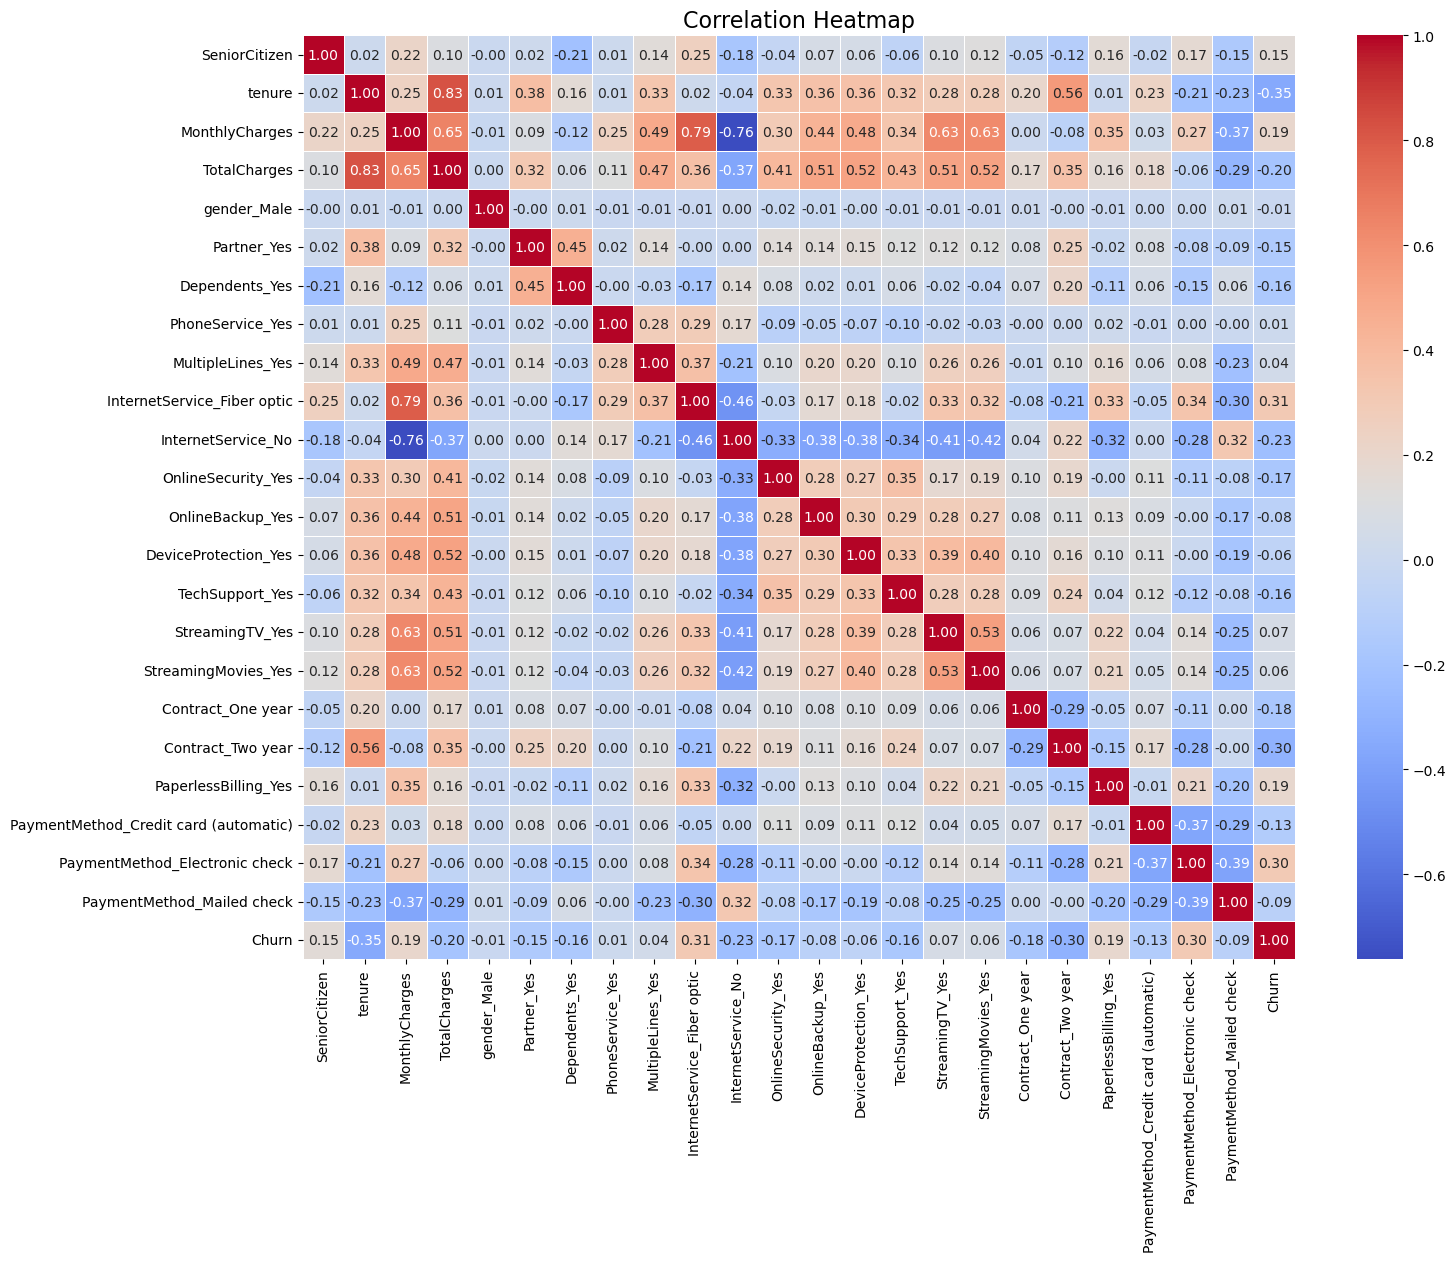

In [109]:
plt.figure(figsize=(16, 12))

corr = X.join(y).corr()

sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap", fontsize=16)
plt.show()


# outliers

In [112]:
numeric_cols = ["tenure", "MonthlyCharges","TotalCharges"]

Q1 = X[numeric_cols].quantile(0.25)
Q3 = X[numeric_cols].quantile(0.75)
IQR = Q3 - Q1


outliers = ((X[numeric_cols] < (Q1 - 1.5 * IQR)) |
            (X[numeric_cols] > (Q3 + 1.5 * IQR)))

print("outliers")
print(outliers.sum())


outliers
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


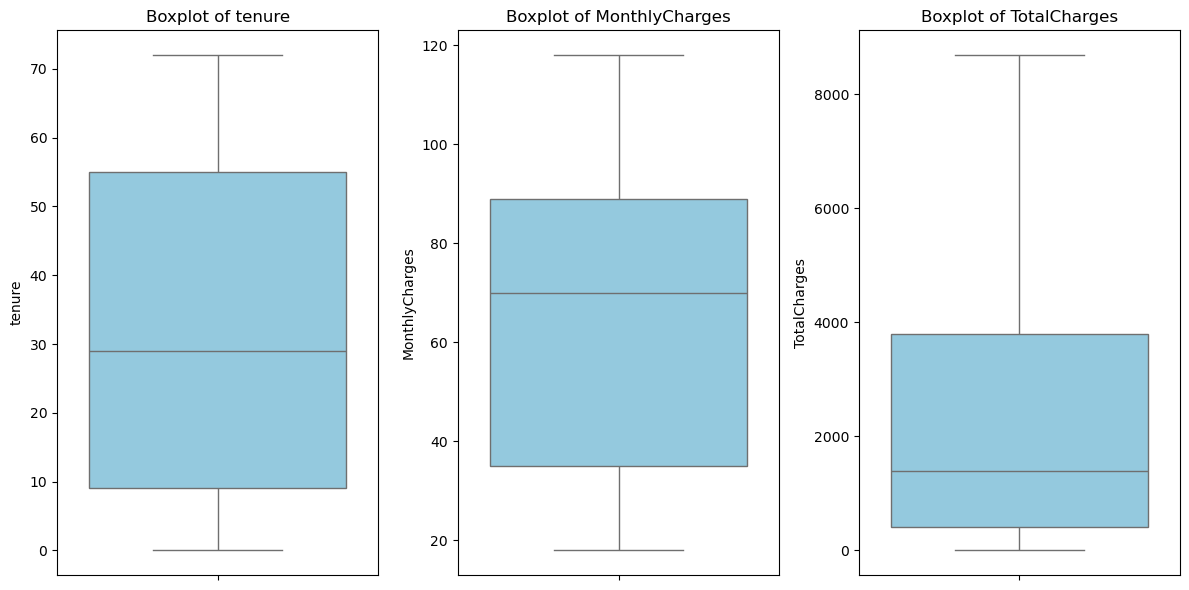

In [114]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=X[col], color="skyblue")
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

# Split and scaling

In [145]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  


# OverSampling 

In [153]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: Churn
0    4131
1    1485
Name: count, dtype: int64
After SMOTE: Churn
1    4131
0    4131
Name: count, dtype: int64


# LogisticRegression

In [158]:
log_reg = LogisticRegression(max_iter=10000, random_state=42)

log_reg.fit(X_train_resampled, y_train_resampled)


y_pred_log = log_reg.predict(X_test_scaled)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))



Confusion Matrix:
 [[759 274]
 [ 88 284]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.76      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.79      0.74      0.76      1405

Accuracy: 0.7423487544483985


# LogisticRegression

In [167]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [171]:
y_pred = log_reg.predict(X_test_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
logistic_accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", logistic_accuracy)

Confusion Matrix:
 [[933 100]
 [177 195]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.52      0.58       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.73      1405
weighted avg       0.79      0.80      0.80      1405


Accuracy: 0.802846975088968


# RandomForest

In [174]:
rf_model = RandomForestClassifier(
    n_estimators=150,
    random_state=45,
    criterion = 'entropy',
    class_weight='balanced'
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       n_estimators=150, random_state=45)

In [176]:
y_pred = rf_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
print(cm)
print('accuracy: ',accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

[[923 110]
 [208 164]]
accuracy:  0.7736654804270463
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.85      1033
           1       0.60      0.44      0.51       372

    accuracy                           0.77      1405
   macro avg       0.71      0.67      0.68      1405
weighted avg       0.76      0.77      0.76      1405



# Grid Search & RandomForest

In [223]:
rf = RandomForestClassifier(random_state=42)

# Grid Search parameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

In [225]:
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=10,
                           scoring='accuracy', n_jobs=-1, verbose=1
                          )

grid_search.fit(X_train_scaled, y_train)

Fitting 10 folds for each of 324 candidates, totalling 3240 fits


GridSearchCV(cv=10, estimator=RandomForestClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced',
                                          'balanced_subsample'],
                         'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=1)

In [229]:
print("Best Parameters:", grid_search.best_params_)


best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test_scaled)


print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
rf_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", rf_accuracy)



Best Parameters: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Confusion Matrix:
 [[940  93]
 [193 179]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.48      0.56       372

    accuracy                           0.80      1405
   macro avg       0.74      0.70      0.71      1405
weighted avg       0.78      0.80      0.79      1405

Accuracy: 0.79644128113879


# Pca

In [232]:
pca_full = PCA()  
pca_full.fit(X_train_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
k = np.argmax(cumvar >= 0.95) + 1   

print(f"Number of components covering ~95% variance: {k}")


Number of components covering ~95% variance: 18


In [234]:
pca = PCA(n_components=k, svd_solver="full", random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)   
X_test_pca  = pca.transform(X_test_scaled)

In [236]:
print("Training shape:", X_train_pca.shape)
print("Testing shape:",  X_test_pca.shape)
print("Total explained variance ratio:", pca.explained_variance_ratio_.sum())

Training shape: (5616, 18)
Testing shape: (1405, 18)
Total explained variance ratio: 0.9645083487817695


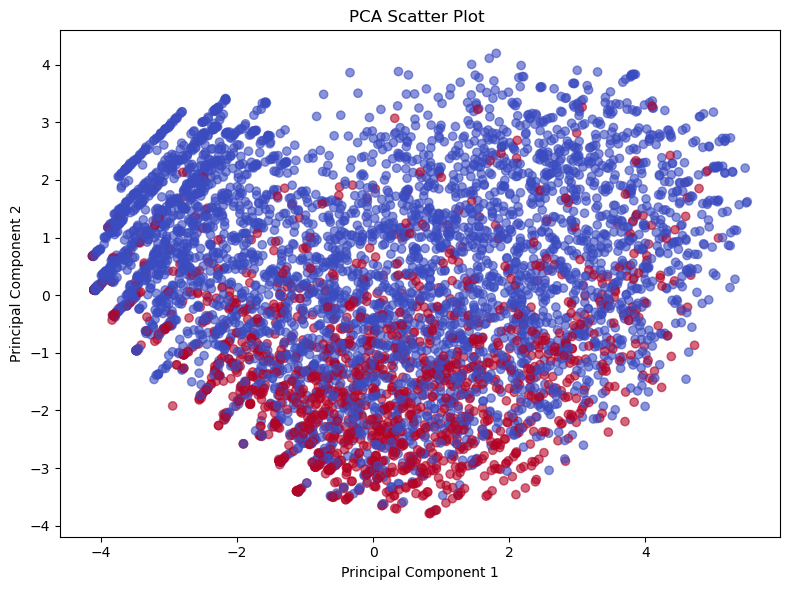

In [238]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_train_pca[:, 0], 
    X_train_pca[:, 1], 
    c=y_train, cmap="coolwarm", alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot ")
plt.tight_layout()
plt.show()

# SVM with Pca

In [195]:
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42, probability=True)

svm_model.fit(X_train_pca, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

In [196]:
y_pred = svm_model.predict(X_test_pca)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Confusion Matrix:
 [[778 255]
 [ 85 287]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.53      0.77      0.63       372

    accuracy                           0.76      1405
   macro avg       0.72      0.76      0.72      1405
weighted avg       0.80      0.76      0.77      1405

Accuracy: 0.7580071174377224


# Grid Search & SVM

In [217]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

In [219]:
grid_search = GridSearchCV(SVC(class_weight='balanced', probability=True, random_state=42),
                           param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train_pca, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=SVC(class_weight='balanced', probability=True,
                           random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': [0.001, 0.01, 0.1, 1],
                         'kernel': ['rbf', 'linear']},
             scoring='accuracy', verbose=1)

In [221]:
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test_pca)

print("Best Parameters:", grid_search.best_params_)
svm_accuracy_after_pca = accuracy_score(y_test, y_pred)
print("Accuracy:", svm_accuracy_after_pca)


Best Parameters: {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
Accuracy: 0.7601423487544484


# KNN 

In [188]:
knn = KNeighborsClassifier(n_neighbors=27 , metric = 'minkowski', p =2)  

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=27)

In [190]:
y_pred = knn.predict(X_test_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
knn_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", knn_accuracy)


Confusion Matrix:
 [[894 139]
 [171 201]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.85      1033
           1       0.59      0.54      0.56       372

    accuracy                           0.78      1405
   macro avg       0.72      0.70      0.71      1405
weighted avg       0.77      0.78      0.78      1405

Accuracy: 0.7793594306049823


# Descion Tree

In [201]:
dt = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=3, min_samples_leaf=5, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=5,
                       random_state=42)

In [203]:
y_pred_dt = dt.predict(X_test_scaled)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", dt_accuracy)

Confusion Matrix:
 [[838 195]
 [148 224]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.81      0.83      1033
           1       0.53      0.60      0.57       372

    accuracy                           0.76      1405
   macro avg       0.69      0.71      0.70      1405
weighted avg       0.77      0.76      0.76      1405

Accuracy: 0.7558718861209964


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning:

X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names



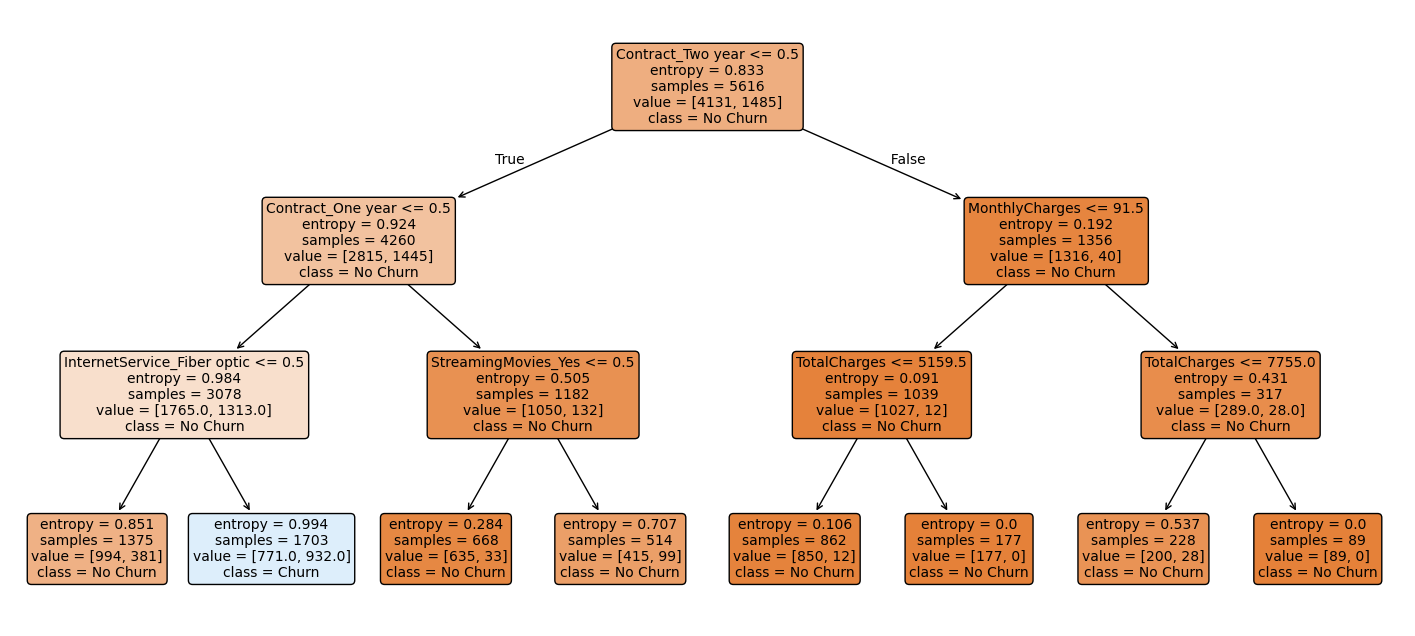

In [244]:
plt.figure(figsize=(18,8))
plot_tree(
    dt, 
    filled=True, 
    feature_names=X_train.columns, 
    class_names=["No Churn", "Churn"], 
    rounded=True, 
    fontsize=10
)
plt.show()

# Grid Search & Descion tree

In [207]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

In [209]:
dt_sc = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt_sc, param_grid, cv=5, scoring='accuracy', verbose=1)

grid_search.fit(X_train_pca, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


C:\Users\DELL\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning:

invalid value encountered in cast



GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy', verbose=1)

In [212]:
best_dt = grid_search.best_estimator_
y_pred_dt_pca_gs = best_dt.predict(X_test_pca)

print("Best Parameters:", grid_search.best_params_)
dt_accuracy_after_pca = accuracy_score(y_test, y_pred_dt_pca_gs)
print("Accuracy:", dt_accuracy_after_pca)

Best Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.7729537366548043


# Compare Models

C:\Users\DELL\AppData\Local\Temp\ipykernel_10480\379669779.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




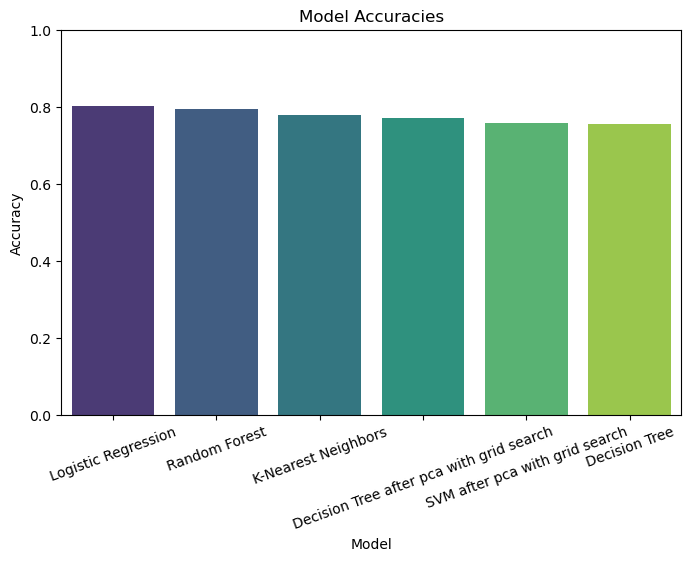

In [240]:
dict_acc = {
    'Logistic Regression': logistic_accuracy,
    'K-Nearest Neighbors': knn_accuracy,
    'Random Forest': rf_accuracy,
    'SVM after pca with grid search': svm_accuracy_after_pca,
    'Decision Tree': dt_accuracy,
    'Decision Tree after pca with grid search': dt_accuracy_after_pca
}
acc_df = pd.DataFrame(dict_acc.items(), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
plt.figure(figsize=(8, 5))
sns.barplot(data=acc_df, x='Model', y='Accuracy', palette='viridis')
plt.title('Model Accuracies')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=20)
plt.show()